In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001474-100507/00001474-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001474-100507/00001474-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001263-100507/00001263-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001263-100507/00001263-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001355-100507/00001355-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001355-100507/00001355-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001208-100507/00001208-100507_ap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF/00001208-100507/00001208-100507_nap.npy
/kaggle/input/datasets/bryandarquea/psg-audio-apnea-

  SLEEP APNEA DETECTION — PSG Audio Dataset

[1/6] Discovering .npy files …
  Apnea files     (_ap.npy)  :    192
  Non-apnea files (_nap.npy) :    191

[2/6] Extracting features (batched + parallel) …
  Batch 1/6  (64 files) … done in 45.9s
  Batch 2/6  (64 files) … done in 32.7s
  Batch 3/6  (64 files) … done in 25.2s
  Batch 4/6  (64 files) … done in 23.3s
  Batch 5/6  (64 files) … done in 25.9s
  Batch 6/6  (63 files) … done in 26.0s

  Feature matrix : (383, 248)  (samples × features)
  Apnea    (1)   : 192
  Non-apnea(0)   : 191

[3/6] Train/test split + StandardScaler …
  Train samples : 306  |  Test samples : 77

[4/6] Hold-out (80/20) training …

  ▶ Training SVM (RBF) … (0.1s)

──────────────────────────────────────────────────
  SVM (RBF)
──────────────────────────────────────────────────
  Accuracy    : 0.7273
  Precision   : 0.7143
  Recall      : 0.7692
  F1-Score    : 0.7407

              precision    recall  f1-score   support

   Non-Apnea       0.74      0.68      0.

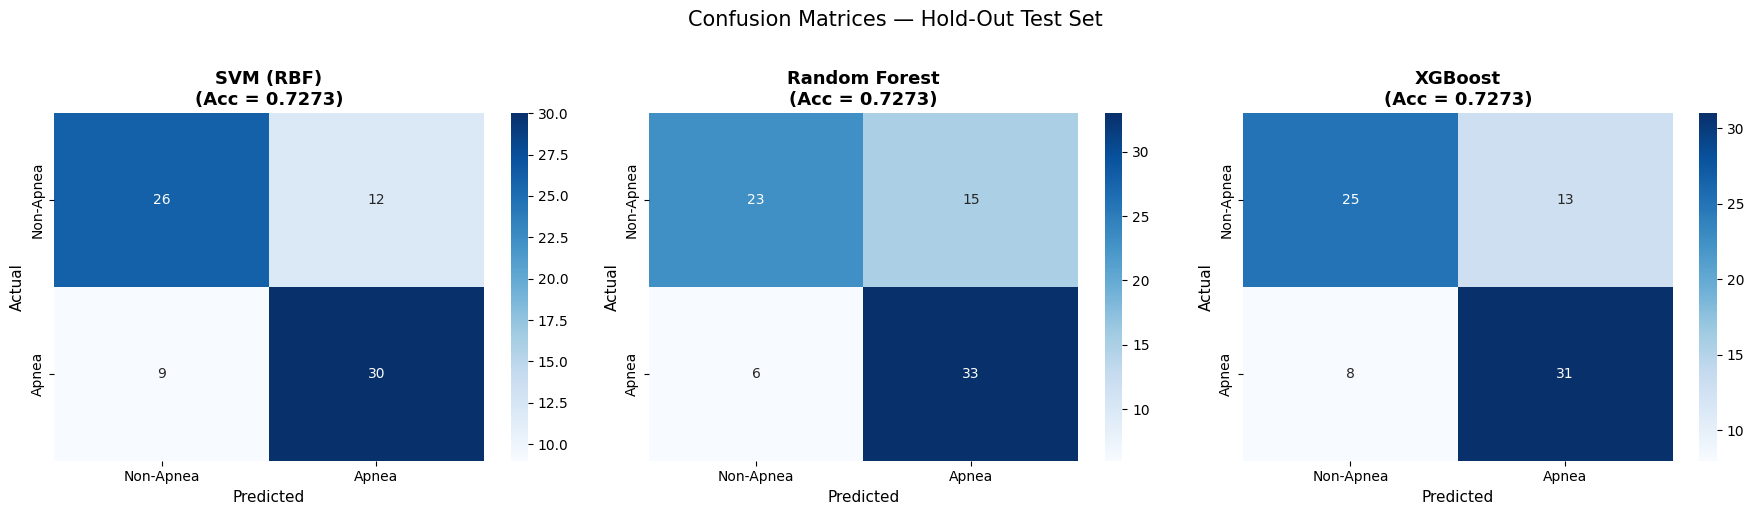

  Saved → confusion_matrices.png


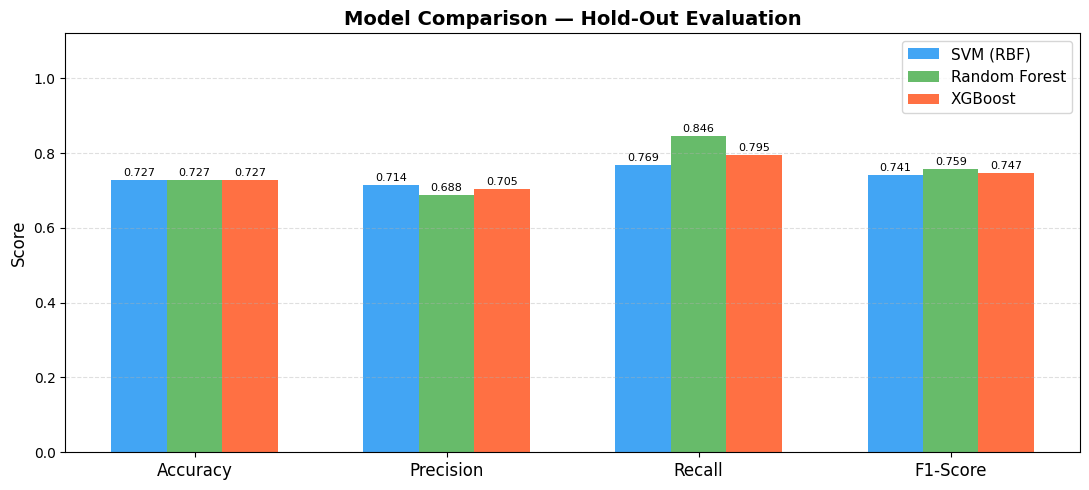

  Saved → model_comparison.png

════════════════════════════════════════════════════
  🏆  Best Model : Random Forest
       F1-Score  : 0.7586
════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────┐
│           TIPS TO FURTHER IMPROVE ACCURACY                  │
├─────────────────────────────────────────────────────────────┤
│  1. DEEP FEATURES                                           │
│     • Use pre-trained PANNs / VGGish CNN embeddings instead │
│       of hand-crafted MFCC for richer representations       │
│     • Fine-tune a 1-D CNN or LSTM on raw audio              │
│                                                             │
│  2. RICHER HAND-CRAFTED FEATURES                            │
│     • Add Chroma, Mel filter bank (MFB), Spectral contrast  │
│     • Add MFCC Δ³ or wavelet sub-band energy features       │
│                                                             │
│  3. DATA AUGMENTATION            

In [2]:
# ============================================================
#  SLEEP APNEA DETECTION — PSG Audio Apnea Dataset
#  End-to-End ML Pipeline for Kaggle
#  Dataset: psg-audio-apnea-audios
#
#  ACTUAL DATASET STRUCTURE:
#  /kaggle/input/psg-audio-apnea-audios/
#  ├── APNEA_types/
#  │   └── <patient>_ap_types.npy       ← apnea type metadata (not used here)
#  └── PSG-AUDIO/
#      └── APNEA_EDF/
#          ├── 00000995-100507/
#          │   ├── 00000995-100507_ap.npy   ← APNEA    (label = 1)
#          │   └── 00000995-100507_nap.npy  ← NON-APNEA (label = 0)
#          ├── 00000999-100507/
#          │   ├── ...
#
#  Labels are derived from filename suffix:
#    *_ap.npy  → 1 (apnea)
#    *_nap.npy → 0 (non-apnea)
# ============================================================
# KAGGLE SETUP — run this cell first if packages are missing:
#   !pip install xgboost librosa scikit-learn --quiet
# ============================================================

import os
import gc
import time
import warnings
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
#  CONFIGURATION  (edit only this block)
# ─────────────────────────────────────────────
CONFIG = {
    # Root folder that contains PSG-AUDIO/APNEA_EDF/<patient>/<files>
    "data_root": "/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF",

    # Audio params
    "sample_rate": 16_000,   # Hz — resample target
    "clip_length": 10,       # seconds — each segment
    "n_mfcc":      40,       # MFCC coefficients (13–40)

    # Training params
    "test_size":     0.20,
    "random_state":  42,
    "n_folds":       5,

    # Kaggle memory/perf limits
    "batch_size": 64,   # files per batch
    "n_workers":   2,   # parallel workers (keep ≤ 2 on Kaggle free tier)
}

SAMPLE_POINTS = CONFIG["sample_rate"] * CONFIG["clip_length"]   # 160 000 samples


# ══════════════════════════════════════════════════════════════
#  1. DATA LOADING
#     Walks PSG-AUDIO/APNEA_EDF/**/ and labels by suffix:
#       *_ap.npy  → 1   (apnea)
#       *_nap.npy → 0   (non-apnea)
# ══════════════════════════════════════════════════════════════

def discover_files(data_root: str) -> list:
    """
    Recursively find all *_ap.npy and *_nap.npy files under data_root.
    Returns a list of (filepath, label) tuples.
    """
    all_npy = glob(os.path.join(data_root, "**", "*.npy"), recursive=True)

    if not all_npy:
        raise FileNotFoundError(
            f"No .npy files found under:\n  {data_root}\n"
            "Check CONFIG['data_root'] — run  !ls /kaggle/input/psg-audio-apnea-audios/  to verify."
        )

    file_label_pairs = []
    skipped = 0
    for path in all_npy:
        fname = os.path.basename(path)
        if fname.endswith("_ap.npy"):
            file_label_pairs.append((path, 1))          # apnea
        elif fname.endswith("_nap.npy"):
            file_label_pairs.append((path, 0))          # non-apnea
        else:
            skipped += 1                                 # e.g. _ap_types.npy — skip

    apnea_count     = sum(1 for _, l in file_label_pairs if l == 1)
    non_apnea_count = sum(1 for _, l in file_label_pairs if l == 0)

    print(f"  Apnea files     (_ap.npy)  : {apnea_count:>6,}")
    print(f"  Non-apnea files (_nap.npy) : {non_apnea_count:>6,}")
    if skipped:
        print(f"  Skipped (other suffix)     : {skipped:>6,}")

    if apnea_count == 0 or non_apnea_count == 0:
        raise ValueError(
            "One class has 0 files — check that the suffix matching (_ap.npy / _nap.npy) is correct."
        )

    return file_label_pairs


def load_npy(filepath: str) -> np.ndarray:
    """
    Load a .npy audio file → flat float32 array.
    Handles mono or multichannel arrays automatically.
    """
    audio = np.load(filepath, allow_pickle=False).astype(np.float32)
    # Collapse multichannel to mono by averaging
    if audio.ndim > 1:
        # Shape could be (channels, samples) or (samples, channels)
        axis = 0 if audio.shape[0] < audio.shape[-1] else -1
        audio = audio.mean(axis=axis)
    return audio.ravel()


# ══════════════════════════════════════════════════════════════
#  2. PREPROCESSING
# ══════════════════════════════════════════════════════════════

def preprocess_audio(audio: np.ndarray,
                     target_len: int = SAMPLE_POINTS) -> np.ndarray:
    """
    1. Pad (wrap-around) or trim to exactly target_len samples.
    2. Peak-normalise to [-1, 1] to equalise recording levels.
    """
    # Wrap-pad avoids the zero-padding silence artifacts
    if len(audio) < target_len:
        repeats = int(np.ceil(target_len / len(audio)))
        audio   = np.tile(audio, repeats)

    audio = audio[:target_len]

    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak

    return audio


# ══════════════════════════════════════════════════════════════
#  3. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════════

def extract_features(audio: np.ndarray,
                     sr: int    = CONFIG["sample_rate"],
                     n_mfcc: int = CONFIG["n_mfcc"]) -> np.ndarray:
    """
    Fixed-size feature vector per audio clip:

      Feature group          | Size
      ─────────────────────────────────
      MFCC   (mean + std)    | 2 × n_mfcc
      MFCC Δ (mean + std)    | 2 × n_mfcc
      MFCC ΔΔ(mean + std)    | 2 × n_mfcc
      Spectral centroid      | 2
      Spectral rolloff       | 2
      Zero-crossing rate     | 2
      RMS energy             | 2
      ─────────────────────────────────
      TOTAL                  | 6×n_mfcc + 8
      (e.g. n_mfcc=40 → 248 features)
    """
    def stat(m):
        return np.concatenate([m.mean(axis=1), m.std(axis=1)])

    mfcc    = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_dd = librosa.feature.delta(mfcc, order=2)

    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    rolloff  = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr      = librosa.feature.zero_crossing_rate(y=audio)
    rms      = librosa.feature.rms(y=audio)

    spec_feat = np.array([
        centroid.mean(), centroid.std(),
        rolloff.mean(),  rolloff.std(),
        zcr.mean(),      zcr.std(),
        rms.mean(),      rms.std(),
    ])

    return np.concatenate([stat(mfcc), stat(mfcc_d), stat(mfcc_dd), spec_feat])


# ─── Worker (must be top-level for multiprocessing pickle) ──────────────────

def _worker_extract(args):
    """Called by ProcessPoolExecutor — one file per call."""
    filepath, label = args
    try:
        audio    = load_npy(filepath)
        audio    = preprocess_audio(audio)
        features = extract_features(audio)
        return features, label
    except Exception as exc:
        print(f"  [SKIP] {os.path.basename(filepath)}: {exc}")
        return None, None


def extract_all_features(file_label_pairs: list,
                         batch_size: int = CONFIG["batch_size"],
                         n_workers:  int = CONFIG["n_workers"]):
    """
    Process all files in small batches using a process pool.
    Batching keeps Kaggle RAM usage flat (gc.collect() between batches).
    Returns X (N × features) and y (N,) as numpy arrays.
    """
    all_features, all_labels = [], []
    total    = len(file_label_pairs)
    n_batches = int(np.ceil(total / batch_size))

    for b_idx in range(n_batches):
        batch = file_label_pairs[b_idx * batch_size: (b_idx + 1) * batch_size]
        print(f"  Batch {b_idx+1}/{n_batches}  ({len(batch)} files) …",
              end=" ", flush=True)
        t0 = time.time()

        with ProcessPoolExecutor(max_workers=n_workers) as pool:
            futures = {pool.submit(_worker_extract, pair): pair for pair in batch}
            for future in as_completed(futures):
                feat, label = future.result()
                if feat is not None:
                    all_features.append(feat)
                    all_labels.append(label)

        gc.collect()
        print(f"done in {time.time()-t0:.1f}s")

    X = np.vstack(all_features).astype(np.float32)
    y = np.array(all_labels, dtype=np.int8)
    print(f"\n  Feature matrix : {X.shape}  (samples × features)")
    print(f"  Apnea    (1)   : {y.sum():,}")
    print(f"  Non-apnea(0)   : {(y == 0).sum():,}")
    return X, y


# ══════════════════════════════════════════════════════════════
#  4. MODEL DEFINITIONS
# ══════════════════════════════════════════════════════════════

def build_models() -> dict:
    """Return a fresh dict of model_name → unfitted estimator."""
    return {
        "SVM (RBF)": SVC(
            kernel="rbf", C=10, gamma="scale",
            probability=True,
            random_state=CONFIG["random_state"],
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=CONFIG["random_state"],
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric="logloss",
            tree_method="hist",          # CPU-efficient; works on Kaggle without GPU
            random_state=CONFIG["random_state"],
            verbosity=0,
        ),
    }


# ══════════════════════════════════════════════════════════════
#  5. TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════

def evaluate(y_true, y_pred, model_name="Model") -> dict:
    """Compute, print, and return metrics dict."""
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1-Score" : f1_score(y_true, y_pred, zero_division=0),
    }
    print(f"\n{'─'*50}")
    print(f"  {model_name}")
    print(f"{'─'*50}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Non-Apnea','Apnea'])}")
    return metrics


def train_hold_out(models: dict,
                   X_train, X_test, y_train, y_test) -> dict:
    """
    Train each model on 80 % and evaluate on 20 %.
    Returns dict: model_name → {model, metrics, y_pred}
    """
    results = {}
    for name, model in models.items():
        print(f"\n  ▶ Training {name} …", end=" ", flush=True)
        t0 = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"({time.time()-t0:.1f}s)")
        metrics = evaluate(y_true=y_test, y_pred=y_pred, model_name=name)
        results[name] = {"model": model, "metrics": metrics, "y_pred": y_pred}
    return results


def train_kfold(models_fn,          # callable → fresh dict of models
                X, y,
                n_folds: int = CONFIG["n_folds"]) -> dict:
    """
    Stratified K-Fold cross-validation.
    Scaling is applied inside each fold to prevent data leakage.
    Returns dict: model_name → list of per-fold F1 scores.
    """
    skf = StratifiedKFold(
        n_splits=n_folds, shuffle=True, random_state=CONFIG["random_state"]
    )
    kfold_results = {name: [] for name in models_fn().keys()}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n  ── Fold {fold}/{n_folds} ──────────────────────────────")
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_val  = scaler.transform(X_val)

        for name, model in models_fn().items():
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            kfold_results[name].append(f1)
            print(f"    {name:<22} F1 = {f1:.4f}")

    print("\n  ── K-Fold Summary ──────────────────────────────────")
    for name, scores in kfold_results.items():
        arr = np.array(scores)
        print(f"    {name:<22} mean F1 = {arr.mean():.4f}  ± {arr.std():.4f}")
    return kfold_results


# ══════════════════════════════════════════════════════════════
#  6. VISUALISATION
# ══════════════════════════════════════════════════════════════

def plot_confusion_matrices(results: dict, y_test):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res["y_pred"])
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-Apnea", "Apnea"],
            yticklabels=["Non-Apnea", "Apnea"],
        )
        acc = res["metrics"]["Accuracy"]
        ax.set_title(f"{name}\n(Acc = {acc:.4f})", fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("Actual",    fontsize=11)

    plt.suptitle("Confusion Matrices — Hold-Out Test Set", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → confusion_matrices.png")


def plot_model_comparison(results: dict):
    metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    model_names  = list(results.keys())
    x     = np.arange(len(metric_names))
    width = 0.22
    colors = ["#2196F3", "#4CAF50", "#FF5722"]

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (name, color) in enumerate(zip(model_names, colors)):
        vals = [results[name]["metrics"][m] for m in metric_names]
        bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(metric_names, fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Comparison — Hold-Out Evaluation", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → model_comparison.png")


def print_winner(results: dict):
    best = max(results, key=lambda n: results[n]["metrics"]["F1-Score"])
    print("\n" + "═" * 52)
    print(f"  🏆  Best Model : {best}")
    print(f"       F1-Score  : {results[best]['metrics']['F1-Score']:.4f}")
    print("═" * 52)


# ══════════════════════════════════════════════════════════════
#  QUICK SANITY CHECK  (run this cell standalone first!)
# ══════════════════════════════════════════════════════════════

def sanity_check():
    """
    Print the first few discovered files and their labels.
    Run this before main() to confirm paths are correct.
    """
    import subprocess
    print("── Directory listing ───────────────────────────────")
    subprocess.run(["find", CONFIG["data_root"], "-name", "*.npy", "-maxdepth", "3"],
                   check=False)
    print("\n── File discovery ──────────────────────────────────")
    pairs = discover_files(CONFIG["data_root"])
    print("\nFirst 6 discovered files:")
    for path, label in pairs[:6]:
        print(f"  label={label}  {os.path.basename(path)}")


# ══════════════════════════════════════════════════════════════
#  7. MAIN PIPELINE
# ══════════════════════════════════════════════════════════════

def main():
    print("=" * 55)
    print("  SLEEP APNEA DETECTION — PSG Audio Dataset")
    print("=" * 55)

    # ── Step 1: Discover files ───────────────────────────────
    print("\n[1/6] Discovering .npy files …")
    file_label_pairs = discover_files(CONFIG["data_root"])

    # ── Step 2: Feature extraction ───────────────────────────
    print("\n[2/6] Extracting features (batched + parallel) …")
    X, y = extract_all_features(
        file_label_pairs,
        batch_size=CONFIG["batch_size"],
        n_workers=CONFIG["n_workers"],
    )

    # ── Step 3: Split & scale ────────────────────────────────
    print("\n[3/6] Train/test split + StandardScaler …")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=CONFIG["test_size"],
        stratify=y,
        random_state=CONFIG["random_state"],
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"  Train samples : {len(y_train):,}  |  Test samples : {len(y_test):,}")

    # ── Step 4: Hold-out training ────────────────────────────
    print("\n[4/6] Hold-out (80/20) training …")
    models  = build_models()
    results = train_hold_out(models, X_train, X_test, y_train, y_test)

    # ── Step 5: K-Fold cross-validation ─────────────────────
    print("\n[5/6] Stratified K-Fold cross-validation …")
    train_kfold(build_models, X, y, n_folds=CONFIG["n_folds"])

    # ── Step 6: Visualisations ───────────────────────────────
    print("\n[6/6] Generating plots …")
    plot_confusion_matrices(results, y_test)
    plot_model_comparison(results)
    print_winner(results)

    # ── Tips ─────────────────────────────────────────────────
    print("""
┌─────────────────────────────────────────────────────────────┐
│           TIPS TO FURTHER IMPROVE ACCURACY                  │
├─────────────────────────────────────────────────────────────┤
│  1. DEEP FEATURES                                           │
│     • Use pre-trained PANNs / VGGish CNN embeddings instead │
│       of hand-crafted MFCC for richer representations       │
│     • Fine-tune a 1-D CNN or LSTM on raw audio              │
│                                                             │
│  2. RICHER HAND-CRAFTED FEATURES                            │
│     • Add Chroma, Mel filter bank (MFB), Spectral contrast  │
│     • Add MFCC Δ³ or wavelet sub-band energy features       │
│                                                             │
│  3. DATA AUGMENTATION                                       │
│     • Time-stretch ±10 %, pitch-shift, Gaussian noise       │
│     • SpecAugment — mask random freq/time bands             │
│                                                             │
│  4. CLASS IMBALANCE HANDLING                                │
│     • SMOTE / ADASYN if one class dominates                 │
│     • class_weight='balanced' in SVM / RF                   │
│     • scale_pos_weight in XGBoost                           │
│                                                             │
│  5. HYPERPARAMETER TUNING                                   │
│     • Optuna Bayesian search on C, gamma, n_estimators …    │
│       (much faster than GridSearchCV)                       │
│                                                             │
│  6. ENSEMBLE                                                │
│     • Soft-voting across SVM + RF + XGBoost                 │
│     • Stacking with Logistic Regression as meta-learner     │
│                                                             │
│  7. FEATURE SELECTION                                       │
│     • Keep top-K features by RF feature_importances_        │
│     • Dimensionality reduction via PCA / UMAP               │
└─────────────────────────────────────────────────────────────┘
""")


# ─── Entry point ────────────────────────────────────────────
if __name__ == "__main__":
    # Uncomment to verify paths before running full pipeline:
    # sanity_check()
    main()

  SLEEP APNEA DETECTION v3 — Upgraded Pipeline

[1/8] Discovering files …
  Apnea files     :   192
  Non-apnea files :   191
  Unique patients :   192
  Skipped files   :     0

[2/8] Extracting base features (batched) …
  Batch 1/6  (64 files) … done in 42.9s
  Batch 2/6  (64 files) … done in 43.4s
  Batch 3/6  (64 files) … done in 42.2s
  Batch 4/6  (64 files) … done in 43.7s
  Batch 5/6  (64 files) … done in 44.5s
  Batch 6/6  (63 files) … done in 42.8s

  Feature matrix : (383, 276)
  Apnea (1)      : 192  |  Non-apnea (0) : 191

[3/8] Patient-level train/test split …
  Train patients : 154  |  samples : 307
  Test  patients : 38  |  samples : 76

[4/8] Scaling features …

[5/8] Tuning XGBoost with Optuna …

  Running Optuna (50 trials) …
  Best trial F1   : 0.8390
  Best params     : {'n_estimators': 581, 'learning_rate': 0.132605151253177, 'max_depth': 10, 'subsample': 0.9215478423004682, 'colsample_bytree': 0.8091742448565397, 'min_child_weight': 3, 'gamma': 1.2003329156932674,

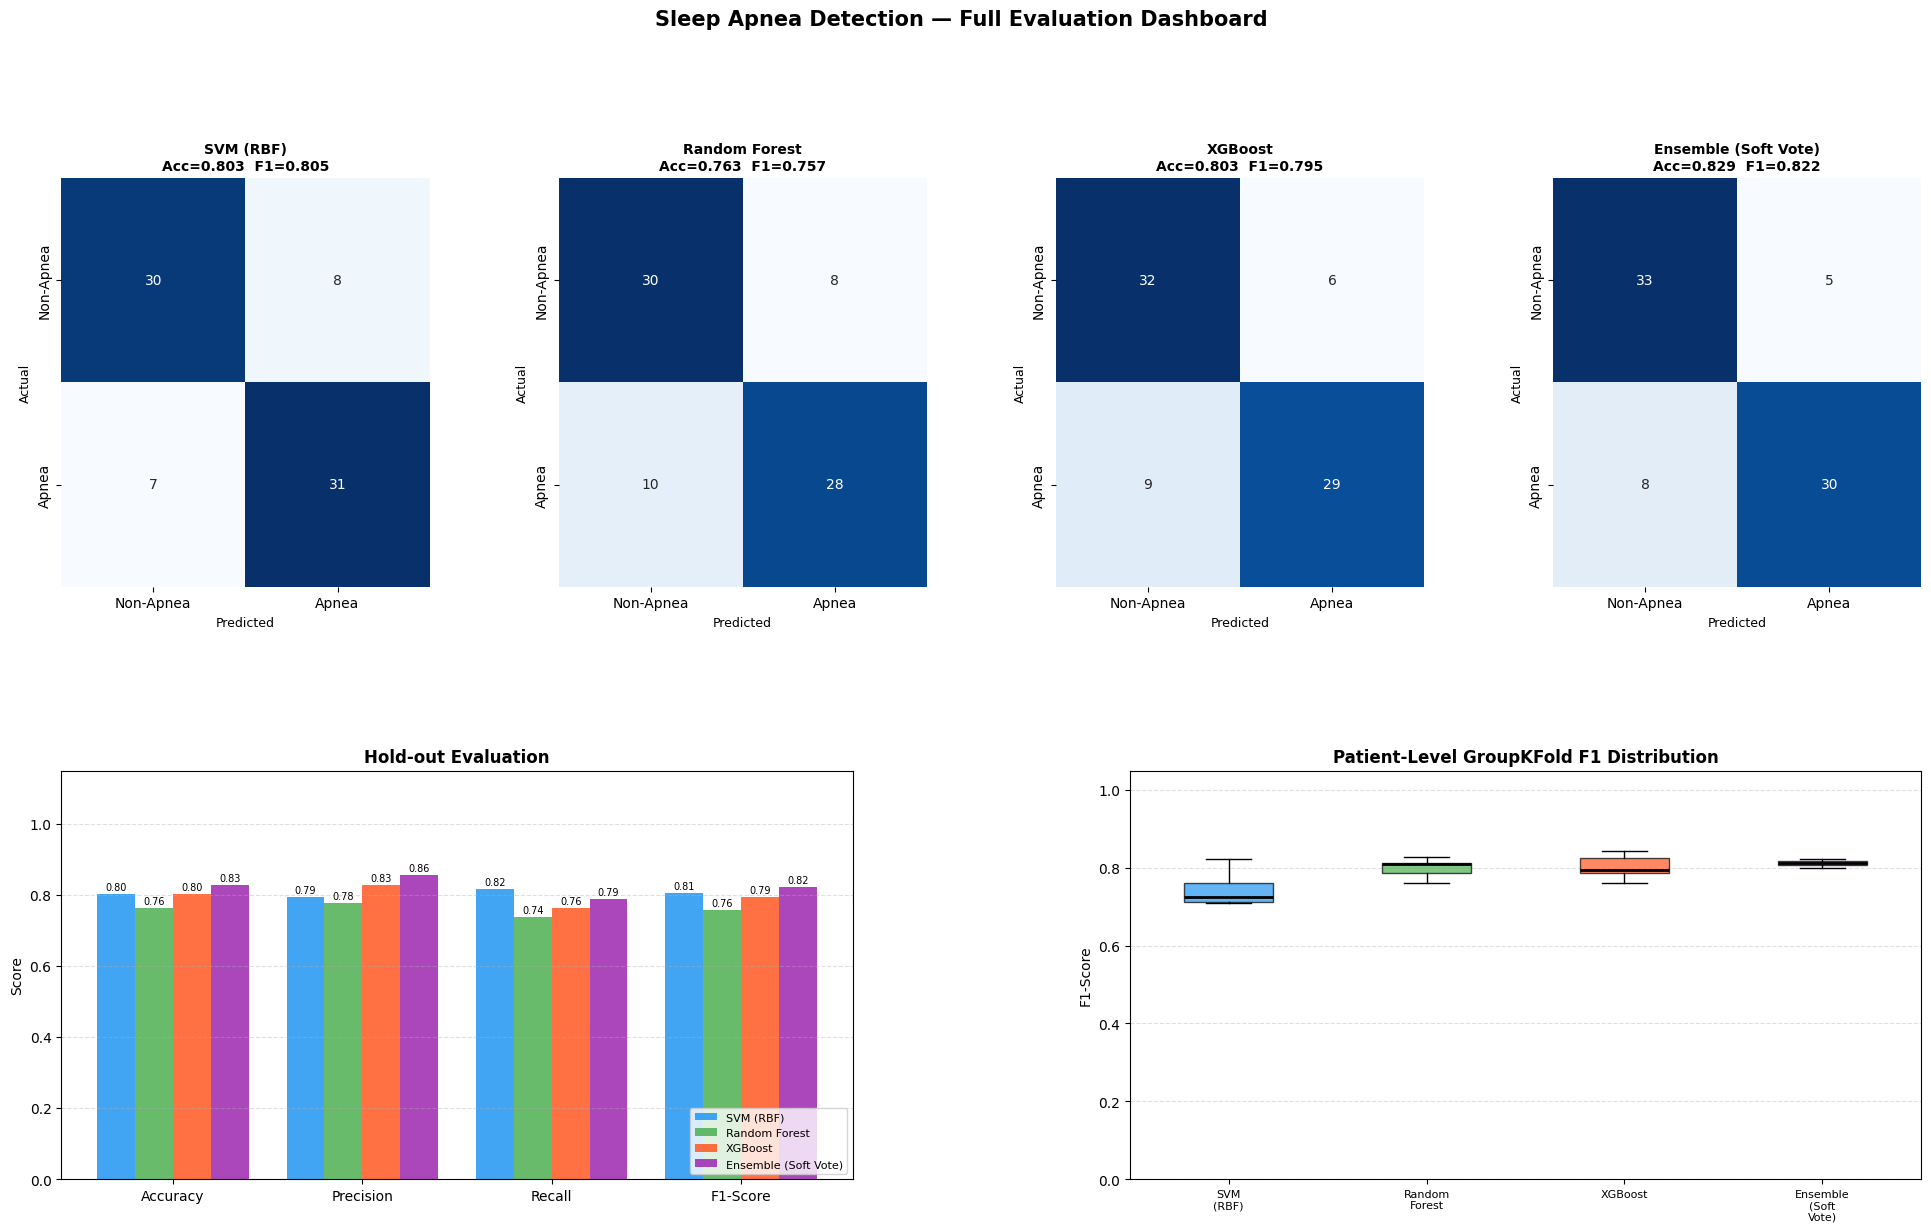

  Saved → apnea_dashboard.png

════════════════════════════════════════════════════════════
  FINAL RANKINGS
════════════════════════════════════════════════════════════

  Model                        Hold-out F1  KFold mean F1
  ───────────────────────────────────────────────────────
   🏆 Ensemble (Soft Vote)            0.8219         0.8120
      XGBoost                         0.7945         0.8023
      Random Forest                   0.7568         0.7999
      SVM (RBF)                       0.8052         0.7462
════════════════════════════════════════════════════════════

  ★  Ranking by K-Fold is more reliable (patient-level,
     larger evaluation set, no leakage).


  Saved → best_apnea_model.pkl  (Ensemble (Soft Vote))


In [4]:
# ============================================================
#  SLEEP APNEA DETECTION v3 — PSG Audio Apnea Dataset
#  UPGRADED PIPELINE — All improvements applied
#
#  Changes from v2:
#   ✅ Patient-level GroupKFold (no data leakage)
#   ✅ Data augmentation (6× clips, train-fold only)
#   ✅ Richer features (Mel, Spectral Contrast, Tonnetz)
#   ✅ Optuna hyperparameter tuning for XGBoost
#   ✅ Soft Voting Ensemble (SVM + RF + XGBoost)
#   ✅ SMOTE for class imbalance (inside each fold)
#   ✅ Best-model saving via joblib
#   ✅ Full evaluation dashboard plot
# ============================================================
# SETUP — run once before executing:
#   !pip install xgboost librosa scikit-learn optuna imbalanced-learn joblib --quiet
# ============================================================

import os, gc, re, time, warnings
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import optuna

from glob import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from sklearn.model_selection import train_test_split, cross_val_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ─────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────
CONFIG = {
    "data_root":    "/kaggle/input/datasets/bryandarquea/psg-audio-apnea-audios/PSG-AUDIO/APNEA_EDF",
    "sample_rate":  16_000,
    "clip_length":  10,          # seconds
    "n_mfcc":       40,          # MFCC coefficients
    "n_mels":       64,          # mel filterbank bins
    "test_size":    0.20,
    "random_state": 42,
    "n_folds":      5,           # GroupKFold folds
    "batch_size":   64,
    "n_workers":    2,
    "optuna_trials": 50,         # set lower (e.g. 20) to save time
    "augment":      True,        # enable/disable augmentation
    "use_smote":    True,        # enable/disable SMOTE
    "save_model":   True,        # save best model to disk
}
SR          = CONFIG["sample_rate"]
SAMPLE_PTS  = SR * CONFIG["clip_length"]   # 160,000


# ══════════════════════════════════════════════════════════════
#  1. DATA LOADING
# ══════════════════════════════════════════════════════════════

def get_patient_id(filepath: str) -> str:
    """
    Extract patient ID from filename.
    '00000995-100507_ap.npy' → '00000995-100507'
    Used for patient-level GroupKFold splits.
    """
    fname = os.path.basename(filepath)
    match = re.match(r"(\d+-\d+)_", fname)
    return match.group(1) if match else fname


def discover_files(data_root: str) -> tuple:
    """
    Walk APNEA_EDF and label by filename suffix.
      *_ap.npy  → 1  (apnea)
      *_nap.npy → 0  (non-apnea)

    Returns:
      file_label_pairs : list of (filepath, label)
      groups           : np.ndarray of patient IDs (for GroupKFold)
    """
    all_npy = glob(os.path.join(data_root, "**", "*.npy"), recursive=True)
    if not all_npy:
        raise FileNotFoundError(f"No .npy files found under: {data_root}")

    pairs, groups = [], []
    skipped = 0
    for path in all_npy:
        fname = os.path.basename(path)
        if fname.endswith("_ap.npy"):
            pairs.append((path, 1))
            groups.append(get_patient_id(path))
        elif fname.endswith("_nap.npy"):
            pairs.append((path, 0))
            groups.append(get_patient_id(path))
        else:
            skipped += 1

    n_ap  = sum(1 for _, l in pairs if l == 1)
    n_nap = sum(1 for _, l in pairs if l == 0)
    n_pat = len(set(groups))
    print(f"  Apnea files     : {n_ap:>5,}")
    print(f"  Non-apnea files : {n_nap:>5,}")
    print(f"  Unique patients : {n_pat:>5,}")
    print(f"  Skipped files   : {skipped:>5,}")

    return pairs, np.array(groups)


def load_npy(filepath: str) -> np.ndarray:
    """Load .npy → flat float32 mono array."""
    audio = np.load(filepath, allow_pickle=False).astype(np.float32)
    if audio.ndim > 1:
        axis  = 0 if audio.shape[0] < audio.shape[-1] else -1
        audio = audio.mean(axis=axis)
    return audio.ravel()


# ══════════════════════════════════════════════════════════════
#  2. PREPROCESSING
# ══════════════════════════════════════════════════════════════

def preprocess_audio(audio: np.ndarray,
                     target_len: int = SAMPLE_PTS) -> np.ndarray:
    """Wrap-pad or trim to fixed length, then peak-normalise."""
    if len(audio) < target_len:
        audio = np.tile(audio, int(np.ceil(target_len / len(audio))))
    audio = audio[:target_len]
    peak  = np.max(np.abs(audio))
    return audio / peak if peak > 1e-6 else audio


# ══════════════════════════════════════════════════════════════
#  3. DATA AUGMENTATION  (applied only inside training folds)
# ══════════════════════════════════════════════════════════════

def augment_audio(audio: np.ndarray, sr: int = SR) -> list:
    """
    Generate 5 augmented variants from one clean clip.
    Returns [original, stretch_slow, stretch_fast,
             pitch_up, pitch_down, noisy]
    """
    variants = [audio]
    try:
        variants.append(librosa.effects.time_stretch(audio, rate=0.90))
        variants.append(librosa.effects.time_stretch(audio, rate=1.10))
        variants.append(librosa.effects.pitch_shift(audio, sr=sr, n_steps= 2))
        variants.append(librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2))
    except Exception:
        pass   # skip if audio too short for effect

    noise = audio + 0.005 * np.random.default_rng(42).standard_normal(len(audio))
    variants.append(noise.astype(np.float32))
    return variants


# ══════════════════════════════════════════════════════════════
#  4. FEATURE EXTRACTION  (richer than v2)
# ══════════════════════════════════════════════════════════════

def extract_features(audio: np.ndarray,
                     sr:    int = SR,
                     n_mfcc: int = CONFIG["n_mfcc"],
                     n_mels: int = CONFIG["n_mels"]) -> np.ndarray:
    """
    Fixed-size feature vector per clip:

    Group                       Dim
    ─────────────────────────────────────────────
    MFCC    mean+std            2 × n_mfcc  = 80
    MFCC Δ  mean+std            2 × n_mfcc  = 80
    MFCC ΔΔ mean+std            2 × n_mfcc  = 80
    Mel-spectrogram mean+std    2            =  2
    Spectral contrast mean+std  2×7          = 14
    Tonnetz mean+std            2×6          = 12
    Spectral centroid mean+std  2            =  2
    Spectral rolloff  mean+std  2            =  2
    ZCR mean+std                2            =  2
    RMS energy mean+std         2            =  2
    ─────────────────────────────────────────────
    TOTAL                                    276
    """
    def stat(m):
        return np.concatenate([m.mean(axis=1), m.std(axis=1)])

    # ── MFCC family ─────────────────────────────────────────
    mfcc    = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_dd = librosa.feature.delta(mfcc, order=2)

    # ── Mel spectrogram ──────────────────────────────────────
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_feat = np.array([mel_db.mean(), mel_db.std()])

    # ── Spectral contrast ────────────────────────────────────
    contrast      = librosa.feature.spectral_contrast(y=audio, sr=sr, n_bands=6)
    contrast_feat = stat(contrast)                     # shape: (7,) → 14

    # ── Tonnetz (harmonic / tonal) ───────────────────────────
    harmonic     = librosa.effects.harmonic(audio)
    tonnetz      = librosa.feature.tonnetz(y=harmonic, sr=sr)
    tonnetz_feat = stat(tonnetz)                       # shape: (6,) → 12

    # ── Scalar spectral features ─────────────────────────────
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    rolloff  = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr      = librosa.feature.zero_crossing_rate(y=audio)
    rms      = librosa.feature.rms(y=audio)

    scalar_feat = np.array([
        centroid.mean(), centroid.std(),
        rolloff.mean(),  rolloff.std(),
        zcr.mean(),      zcr.std(),
        rms.mean(),      rms.std(),
    ])

    return np.concatenate([
        stat(mfcc), stat(mfcc_d), stat(mfcc_dd),
        mel_feat, contrast_feat, tonnetz_feat, scalar_feat,
    ])


# ── Worker (top-level required for multiprocessing) ──────────
def _worker_extract(args):
    filepath, label = args
    try:
        audio = preprocess_audio(load_npy(filepath))
        feat  = extract_features(audio)
        return feat, label
    except Exception as exc:
        print(f"  [SKIP] {os.path.basename(filepath)}: {exc}")
        return None, None


def extract_all_features(file_label_pairs: list,
                         batch_size: int = CONFIG["batch_size"],
                         n_workers:  int = CONFIG["n_workers"]) -> tuple:
    """Batched parallel feature extraction. Returns X, y."""
    all_feats, all_labels = [], []
    n_batches = int(np.ceil(len(file_label_pairs) / batch_size))

    for b in range(n_batches):
        batch = file_label_pairs[b * batch_size: (b + 1) * batch_size]
        print(f"  Batch {b+1}/{n_batches}  ({len(batch)} files) …",
              end=" ", flush=True)
        t0 = time.time()
        with ProcessPoolExecutor(max_workers=n_workers) as pool:
            for feat, label in pool.map(_worker_extract, batch):
                if feat is not None:
                    all_feats.append(feat)
                    all_labels.append(label)
        gc.collect()
        print(f"done in {time.time()-t0:.1f}s")

    X = np.vstack(all_feats).astype(np.float32)
    y = np.array(all_labels, dtype=np.int8)
    print(f"\n  Feature matrix : {X.shape}")
    print(f"  Apnea (1)      : {y.sum():,}  |  Non-apnea (0) : {(y==0).sum():,}")
    return X, y


# ══════════════════════════════════════════════════════════════
#  5. OPTUNA HYPERPARAMETER TUNING  (XGBoost)
# ══════════════════════════════════════════════════════════════

def tune_xgboost(X_train: np.ndarray, y_train: np.ndarray,
                 n_trials: int = CONFIG["optuna_trials"]) -> dict:
    """
    Bayesian search over XGBoost hyperparameters using 5-fold CV.
    Returns the best parameter dict.
    """
    print(f"\n  Running Optuna ({n_trials} trials) …")

    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int  ("n_estimators",      100, 600),
            "learning_rate":     trial.suggest_float ("learning_rate",     0.01, 0.3,  log=True),
            "max_depth":         trial.suggest_int  ("max_depth",          3, 10),
            "subsample":         trial.suggest_float ("subsample",         0.5, 1.0),
            "colsample_bytree":  trial.suggest_float ("colsample_bytree",  0.5, 1.0),
            "min_child_weight":  trial.suggest_int  ("min_child_weight",   1, 10),
            "gamma":             trial.suggest_float ("gamma",             0.0, 5.0),
            "reg_alpha":         trial.suggest_float ("reg_alpha",         1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float ("reg_lambda",        1e-8, 10.0, log=True),
            "tree_method": "hist", "eval_metric": "logloss",
            "random_state": CONFIG["random_state"], "verbosity": 0,
        }
        model  = XGBClassifier(**params)
        scores = cross_val_score(model, X_train, y_train, cv=5,
                                 scoring="f1", n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=CONFIG["random_state"]))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    print(f"  Best trial F1   : {study.best_value:.4f}")
    print(f"  Best params     : {study.best_params}")
    return study.best_params


# ══════════════════════════════════════════════════════════════
#  6. MODEL BUILDING
# ══════════════════════════════════════════════════════════════

def build_base_models(xgb_params: dict = None) -> dict:
    """Return fresh model instances (called per fold to prevent leakage)."""
    xgb_cfg = dict(
        tree_method="hist", eval_metric="logloss",
        random_state=CONFIG["random_state"], verbosity=0,
    )
    if xgb_params:
        xgb_cfg.update(xgb_params)
    else:
        xgb_cfg.update(dict(n_estimators=300, learning_rate=0.05,
                            max_depth=6, subsample=0.8, colsample_bytree=0.8))

    return {
        "SVM (RBF)": SVC(
            kernel="rbf", C=10, gamma="scale",
            probability=True, class_weight="balanced",
            random_state=CONFIG["random_state"],
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=None,
            min_samples_leaf=2, class_weight="balanced",
            n_jobs=-1, random_state=CONFIG["random_state"],
        ),
        "XGBoost": XGBClassifier(**xgb_cfg),
    }


def build_ensemble(xgb_params: dict = None) -> VotingClassifier:
    """Soft-voting ensemble of SVM + RF + XGBoost."""
    models = build_base_models(xgb_params)
    return VotingClassifier(
        estimators=list(models.items()),
        voting="soft",
        n_jobs=-1,
    )


# ══════════════════════════════════════════════════════════════
#  7. TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════

def evaluate(y_true, y_pred, model_name="Model") -> dict:
    metrics = {
        "Accuracy" : accuracy_score (y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score   (y_true, y_pred, zero_division=0),
        "F1-Score" : f1_score       (y_true, y_pred, zero_division=0),
    }
    print(f"\n{'─'*52}")
    print(f"  {model_name}")
    print(f"{'─'*52}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Non-Apnea','Apnea'])}")
    return metrics


def train_hold_out(X_train, X_test, y_train, y_test,
                   xgb_params: dict = None) -> dict:
    """
    Train all models + ensemble on the 80% hold-out split.
    Applies SMOTE on training data if enabled.
    """
    # Optional SMOTE
    if CONFIG["use_smote"]:
        sm = SMOTE(random_state=CONFIG["random_state"])
        X_train, y_train = sm.fit_resample(X_train, y_train)
        print(f"  After SMOTE → train samples: {len(y_train):,}")

    all_models = build_base_models(xgb_params)
    all_models["Ensemble (Soft Vote)"] = build_ensemble(xgb_params)

    results = {}
    for name, model in all_models.items():
        print(f"\n  ▶ Training {name} …", end=" ", flush=True)
        t0 = time.time()
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        print(f"({time.time()-t0:.1f}s)")
        metrics = evaluate(y_true=y_test, y_pred=y_pred, model_name=name)
        results[name] = {"model": model, "metrics": metrics, "y_pred": y_pred}
    return results


def train_group_kfold(X: np.ndarray, y: np.ndarray,
                      groups: np.ndarray,
                      file_label_pairs: list,
                      xgb_params: dict = None) -> dict:
    """
    Patient-level GroupKFold cross-validation.
    Augmentation and SMOTE are applied INSIDE each training fold only.
    Returns dict: model_name → list of per-fold F1 scores.
    """
    gkf = GroupKFold(n_splits=CONFIG["n_folds"])
    kfold_scores = {
        "SVM (RBF)": [], "Random Forest": [],
        "XGBoost": [], "Ensemble (Soft Vote)": [],
    }

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
        print(f"\n  ── Fold {fold}/{CONFIG['n_folds']} ─────────────────────────────")
        X_tr, X_val = X[tr_idx].copy(), X[val_idx]
        y_tr, y_val = y[tr_idx].copy(), y[val_idx]

        # ── Augmentation on training fold ────────────────────
        if CONFIG["augment"]:
            aug_feats, aug_labels = [], []
            for idx in tr_idx:
                fp, label = file_label_pairs[idx]
                try:
                    raw = preprocess_audio(load_npy(fp))
                    for variant in augment_audio(raw)[1:]:   # skip original (already in X)
                        aug_feats.append(extract_features(preprocess_audio(variant)))
                        aug_labels.append(label)
                except Exception:
                    pass
            if aug_feats:
                X_tr = np.vstack([X_tr, np.vstack(aug_feats)])
                y_tr = np.concatenate([y_tr, aug_labels])
                print(f"    After augmentation → {len(y_tr):,} train samples")

        # ── Scale ─────────────────────────────────────────────
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_val  = scaler.transform(X_val)

        # ── SMOTE ─────────────────────────────────────────────
        if CONFIG["use_smote"]:
            sm = SMOTE(random_state=CONFIG["random_state"])
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        # ── Train & score ─────────────────────────────────────
        all_models = build_base_models(xgb_params)
        all_models["Ensemble (Soft Vote)"] = build_ensemble(xgb_params)

        for name, model in all_models.items():
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            kfold_scores[name].append(f1)
            print(f"    {name:<26} F1 = {f1:.4f}")

        gc.collect()

    print("\n  ── GroupKFold Summary ──────────────────────────────")
    for name, scores in kfold_scores.items():
        arr = np.array(scores)
        print(f"    {name:<26} mean F1 = {arr.mean():.4f}  ± {arr.std():.4f}")
    return kfold_scores


# ══════════════════════════════════════════════════════════════
#  8. VISUALISATION
# ══════════════════════════════════════════════════════════════

def plot_all(results: dict, kfold_scores: dict, y_test):
    """
    Combined dashboard:
      Row 1 — Confusion matrices (one per model)
      Row 2 — Hold-out bar chart | K-Fold box plot
    """
    model_names  = list(results.keys())
    n_models     = len(model_names)
    colors       = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]

    fig = plt.figure(figsize=(6 * n_models, 13))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            hspace=0.45, wspace=0.35)

    # ── Row 1: Confusion matrices ────────────────────────────
    cm_gs = gridspec.GridSpecFromSubplotSpec(
        1, n_models, subplot_spec=gs[0, :], wspace=0.35
    )
    for i, name in enumerate(model_names):
        ax  = fig.add_subplot(cm_gs[i])
        cm  = confusion_matrix(y_test, results[name]["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Non-Apnea", "Apnea"],
                    yticklabels=["Non-Apnea", "Apnea"],
                    cbar=False)
        acc = results[name]["metrics"]["Accuracy"]
        f1  = results[name]["metrics"]["F1-Score"]
        ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Actual",    fontsize=9)

    # ── Row 2 left: Hold-out bar chart ───────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    x     = np.arange(len(metric_names))
    width = 0.20
    for i, (name, color) in enumerate(zip(model_names, colors)):
        vals = [results[name]["metrics"][m] for m in metric_names]
        bars = ax2.bar(x + i * width, vals, width,
                       label=name, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax2.set_xticks(x + width * (n_models - 1) / 2)
    ax2.set_xticklabels(metric_names, fontsize=10)
    ax2.set_ylim(0, 1.15)
    ax2.set_ylabel("Score", fontsize=10)
    ax2.set_title("Hold-out Evaluation", fontsize=12, fontweight="bold")
    ax2.legend(fontsize=8, loc="lower right")
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Row 2 right: K-Fold box plot ─────────────────────────
    ax3   = fig.add_subplot(gs[1, 1])
    kdata = [kfold_scores[n] for n in model_names]
    bp    = ax3.boxplot(kdata, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax3.set_xticklabels(
        [n.replace(" ", "\n") for n in model_names], fontsize=8
    )
    ax3.set_ylabel("F1-Score", fontsize=10)
    ax3.set_title("Patient-Level GroupKFold F1 Distribution",
                  fontsize=12, fontweight="bold")
    ax3.grid(axis="y", linestyle="--", alpha=0.4)
    ax3.set_ylim(0, 1.05)

    fig.suptitle("Sleep Apnea Detection — Full Evaluation Dashboard",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.savefig("apnea_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → apnea_dashboard.png")


def print_winner(results: dict, kfold_scores: dict):
    """Print rankings by hold-out F1 and by K-Fold mean F1."""
    print("\n" + "═" * 60)
    print("  FINAL RANKINGS")
    print("═" * 60)
    print(f"\n  {'Model':<28} {'Hold-out F1':>11}  {'KFold mean F1':>13}")
    print(f"  {'─'*55}")
    rows = []
    for name in results:
        ho   = results[name]["metrics"]["F1-Score"]
        kf   = np.mean(kfold_scores[name]) if name in kfold_scores else float("nan")
        rows.append((name, ho, kf))
    rows.sort(key=lambda r: r[2], reverse=True)   # sort by KFold (more reliable)
    for i, (name, ho, kf) in enumerate(rows):
        crown = " 🏆" if i == 0 else "   "
        print(f"  {crown} {name:<26} {ho:>11.4f}  {kf:>13.4f}")
    print("═" * 60)
    print("\n  ★  Ranking by K-Fold is more reliable (patient-level,")
    print("     larger evaluation set, no leakage).\n")


# ══════════════════════════════════════════════════════════════
#  9. SAVE BEST MODEL
# ══════════════════════════════════════════════════════════════

def save_best_model(results: dict, scaler: StandardScaler):
    """Save best model + scaler (needed for inference)."""
    best_name  = max(results, key=lambda n: results[n]["metrics"]["F1-Score"])
    best_model = results[best_name]["model"]
    bundle     = {"model": best_model, "scaler": scaler,
                  "model_name": best_name,
                  "feature_dim": scaler.n_features_in_}
    joblib.dump(bundle, "best_apnea_model.pkl")
    print(f"\n  Saved → best_apnea_model.pkl  ({best_name})")


# ══════════════════════════════════════════════════════════════
#  10. MAIN PIPELINE
# ══════════════════════════════════════════════════════════════

def main():
    print("=" * 58)
    print("  SLEEP APNEA DETECTION v3 — Upgraded Pipeline")
    print("=" * 58)

    # ── 1. Discover ──────────────────────────────────────────
    print("\n[1/8] Discovering files …")
    file_label_pairs, groups = discover_files(CONFIG["data_root"])

    # ── 2. Feature extraction ────────────────────────────────
    print("\n[2/8] Extracting base features (batched) …")
    X, y = extract_all_features(file_label_pairs)

    # ── 3. Patient-level split ───────────────────────────────
    print("\n[3/8] Patient-level train/test split …")
    # Use unique patients for splitting (no patient in both sets)
    unique_patients = list(dict.fromkeys(groups))   # preserve order, deduplicated
    n_test_pat      = max(1, int(len(unique_patients) * CONFIG["test_size"]))

    rng = np.random.default_rng(CONFIG["random_state"])
    test_patients   = set(rng.choice(unique_patients, n_test_pat, replace=False))
    train_patients  = set(unique_patients) - test_patients

    tr_mask  = np.array([g in train_patients for g in groups])
    te_mask  = ~tr_mask

    X_train, X_test = X[tr_mask], X[te_mask]
    y_train, y_test = y[tr_mask], y[te_mask]
    file_label_train = [file_label_pairs[i] for i in np.where(tr_mask)[0]]

    print(f"  Train patients : {len(train_patients)}  |  samples : {len(y_train):,}")
    print(f"  Test  patients : {len(test_patients)}  |  samples : {len(y_test):,}")

    # ── 4. Scale ─────────────────────────────────────────────
    print("\n[4/8] Scaling features …")
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── 5. Optuna tuning ─────────────────────────────────────
    print("\n[5/8] Tuning XGBoost with Optuna …")
    xgb_best_params = tune_xgboost(X_train, y_train,
                                   n_trials=CONFIG["optuna_trials"])

    # ── 6. Hold-out training ─────────────────────────────────
    print("\n[6/8] Hold-out training (all models + ensemble) …")
    results = train_hold_out(X_train, X_test, y_train, y_test,
                             xgb_params=xgb_best_params)

    # ── 7. GroupKFold CV ─────────────────────────────────────
    print("\n[7/8] Patient-level GroupKFold cross-validation …")
    groups_train = groups[tr_mask]
    kfold_scores = train_group_kfold(
        X_train, y_train, groups_train,
        file_label_train,
        xgb_params=xgb_best_params,
    )

    # ── 8. Report ─────────────────────────────────────────────
    print("\n[8/8] Visualising results …")
    plot_all(results, kfold_scores, y_test)
    print_winner(results, kfold_scores)

    if CONFIG["save_model"]:
        save_best_model(results, scaler)


# ── Inference helper (load saved model and predict one clip) ──
def predict_clip(filepath: str, bundle_path: str = "best_apnea_model.pkl"):
    """
    Predict apnea / non-apnea for a single .npy file.
    Usage:
        label, prob = predict_clip("/path/to/clip_ap.npy")
    """
    bundle = joblib.load(bundle_path)
    audio  = preprocess_audio(load_npy(filepath))
    feat   = extract_features(audio).reshape(1, -1)
    feat   = bundle["scaler"].transform(feat)
    pred   = bundle["model"].predict(feat)[0]
    prob   = bundle["model"].predict_proba(feat)[0]
    result = "APNEA" if pred == 1 else "NON-APNEA"
    print(f"  Prediction : {result}  (apnea prob = {prob[1]:.3f})")
    return int(pred), prob


# ── Entry point ───────────────────────────────────────────────
if __name__ == "__main__":
    main()